# Data Science Project: Big Mart Sales Analysis

In [8]:
# Load in the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Load in our dataset from Kaggle in a .csv format

In [9]:
# Read in the data from our csv file containing item and outlet sales information
df_groceries = pd.read_csv('../data/big_mart_sales.csv', delimiter=',', header='infer')

# Report information regarding the dataset

df_groceries.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [10]:
# Show the first 5 rows of the dataset
df_groceries.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Handling empty data entries

In [14]:
# Let's identify the columns that contain missing values or entries containing Nan or None
missing_values = df_groceries.isnull().sum()
print(missing_values)

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


### Missing data

Item weight and outlet size are missing for some rows. To take care of item weight lets use the median for item's of the same type as a placeholder. For outlet size let's use the mode for outlets with the same type since the data is stored as strings.

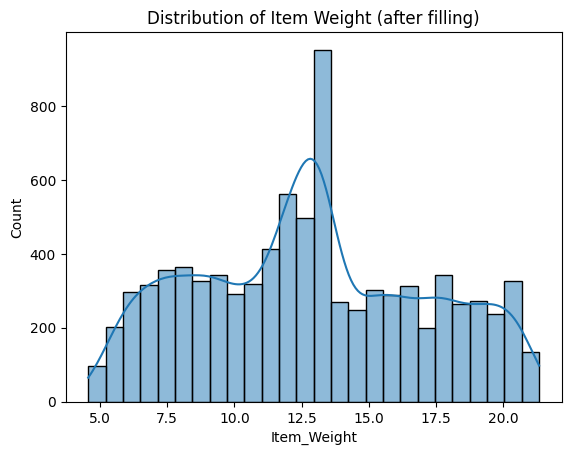

In [ ]:
# Visualise the missing Item Weight data with Seaborn and Matplotlib
sns.histplot(df_groceries["Item_Weight"], kde=True)
plt.title("Distribution of Item Weight (Missing Values)")
plt.show()


In [ ]:
# Visualise the missing Outlet Size data with Seaborn and Matplotlib


In [13]:
# Item Weight
df_groceries['Item_Weight'] = df_groceries['Item_Weight'].fillna(df_groceries.groupby("Item_Type")["Item_Weight"].transform("median"))

In [15]:
# Outlet Size
df_groceries['Outlet_Size'] = df_groceries['Outlet_Size'].fillna(df_groceries.groupby("Outlet_Type")["Outlet_Size"].transform("mean"))

TypeError: dtype 'str' does not support operation 'mean'

## Exploratory Data Analysis Using Seaborn

Our analysis is primarily concerned with the following categories:
    1. 